# Viral — 전체 가입 추이

가입 증가를 기술합니다. 가입자 수만으로 바이럴 유입 경로를 입증하지 않습니다.

## 공통 기준
- 현재 네트워크 스냅샷의 일반 계정(운영·관리 계정 제외)을 사용자 ID로 중복 제거합니다.
- 학교 ID는 현재 스냅샷의 학교입니다. 과거 전학·탈퇴 이력까지 복원한 모집단은 아닙니다.
- D0는 이 모집단의 누적 가입자가 처음 40명에 도달한 날짜입니다. 실제 기능 활성화 로그 시점과 구분합니다.
- 확산 유형은 2023년 4~5월 D0 도달 학교에서 D+1~7, D+8~14 가입자 수의 각각 중앙값으로 분류합니다.
- 최초 가입 후 7·14일과 D0 전후 구간은 서로 다른 시간 기준입니다.
- 유형은 사후 구간으로 분류한 기술 통계입니다. 예측 변수나 인과 효과로 해석하지 않습니다.
- 원본과 동일하게 가입 기록이 없는 학교·일은 0명으로 처리합니다. 추출 범위 밖의 기간을 무가입으로 간주하지 않도록 원본 데이터의 관찰기간을 확인해야 합니다.

In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from IPython.display import display

# 기본 구조: 같은 상위 폴더 아래 team7/ 와 team7_marts/
# 다른 위치면 이 한 줄에 실제 폴더 경로를 입력합니다.
DATA_DIR_OVERRIDE = os.environ.get("TEAM7_MARTS_DIR", "")
if DATA_DIR_OVERRIDE:
    data_dir = Path(DATA_DIR_OVERRIDE).expanduser().resolve()
else:
    current = Path.cwd().resolve()
    candidates = []
    for parent in [current, *current.parents]:
        candidates.extend([parent / "team7_marts", parent.parent / "team7_marts"])
    data_dir = next((p for p in candidates if p.is_dir()), None)
    if data_dir is None:
        raise FileNotFoundError("team7_marts 폴더가 없습니다. DATA_DIR_OVERRIDE에 실제 폴더 경로를 입력하세요.")
if not data_dir.is_dir():
    raise FileNotFoundError(f"데이터 폴더가 없습니다: {data_dir}")
print("데이터 폴더:", data_dir)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]:
    if font in fonts:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False

def read_mart(filename, required):
    path = data_dir / filename
    if not path.is_file():
        raise FileNotFoundError(f"필요한 마트가 없습니다: {path}")
    frame = pd.read_csv(path, low_memory=False, na_values=[r"\N"])
    missing = sorted(set(required) - set(frame.columns))
    if missing:
        raise ValueError(f"{filename}: 필수 컬럼 누락 {missing}")
    return frame

network = read_mart("mart_user_network_snapshot.csv", [
    "user_id", "school_id", "user_created_at", "is_staff", "is_superuser"
])
for column in ["is_staff", "is_superuser"]:
    network[column] = pd.to_numeric(network[column], errors="coerce")

데이터 폴더: /Users/jangjunyoung/DA15_Part4/team7_marts


In [ ]:
# ============================================================
# 2. 분석용 사용자 데이터 정리
# ============================================================

users = network.copy()

# 관리자·운영 계정 제외
users = users[
    users["is_superuser"].fillna(0).eq(0)
    & users["is_staff"].fillna(0).eq(0)
].copy()

# 자료형 변환
users["school_id"] = pd.to_numeric(
    users["school_id"],
    errors="coerce"
)

users["user_id"] = pd.to_numeric(
    users["user_id"],
    errors="coerce"
)

users["user_created_at"] = pd.to_datetime(
    users["user_created_at"],
    errors="coerce"
)

# 분석 필수값이 없는 행 제외
users = users.dropna(
    subset=["user_id", "school_id", "user_created_at"]
).copy()

users["user_id"] = users["user_id"].astype("int64")
users["school_id"] = users["school_id"].astype("int64")
users["signup_date"] = users["user_created_at"].dt.normalize()
users["signup_month"] = (
    users["signup_date"]
    .dt.to_period("M")
    .astype(str)
)

# 사용자 중복 제거
users = (
    users
    .sort_values("user_created_at")
    .drop_duplicates("user_id", keep="first")
    .reset_index(drop=True)
)

print("분석 사용자 수:", f"{users['user_id'].nunique():,}명")
print("분석 학교 수:", f"{users['school_id'].nunique():,}개")
print(
    "가입일 범위:",
    users["signup_date"].min(),
    "~",
    users["signup_date"].max()
)

display(users.head())

분석 사용자 수: 677,080명
분석 학교 수: 5,551개
가입일 범위: 2023-03-29 00:00:00 ~ 2024-05-09 00:00:00


,mart_built_at,user_id,gender,user_created_at,is_superuser,is_staff,ban_status,group_id,grade,class_num,school_id,school_address,school_type,student_count,current_friend_count_snapshot,network_degree_count,mutual_friend_count,one_way_friend_count,valid_outbound_listing_count,valid_inbound_listing_count,same_school_friend_count,same_grade_friend_count,same_group_friend_count,unknown_school_relation_count,orphan_friend_reference_count,duplicate_friend_reference_count,is_isolated_current_snapshot,is_isolated_valid_network,is_inbound_only_user,reciprocity_rate,same_school_friend_rate,same_group_friend_rate,degree_centrality,sent_request_count,sent_accepted_count,sent_pending_count,sent_rejected_count,received_request_count,received_accepted_count,received_pending_count,received_rejected_count,total_request_activity_count,accepted_request_record_count,pending_request_record_count,rejected_request_record_count,accepted_request_partner_count,has_accepted_request_partner,repeated_accepted_request_count,sent_acceptance_rate,received_acceptance_rate,sent_decision_acceptance_rate,received_decision_acceptance_rate,network_status,request_status,signup_date,signup_month
0,2026-09-02 00:47:38.728474,831962,F,2023-03-29 05:18:56.162368,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,43,31,31,0,31,31,25,2,0,0,12,0,0,0,0,1.00,0.81,0.00,0.00,1,1,0,0,26,0,26,0,27,1,26,0,1,1,0,1.00,0.00,1.00,NaN,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
1,2026-09-02 00:47:38.728474,832151,M,2023-03-29 12:56:34.989468,0,0,N,1.00,1.00,1.00,1,NaN,NaN,NaN,51,50,50,0,50,50,45,35,32,0,1,0,0,0,0,1.00,0.90,0.64,0.00,10,2,8,0,35,6,29,0,45,8,37,0,8,1,0,0.20,0.17,1.00,1.00,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
2,2026-09-02 00:47:38.728474,832340,F,2023-03-29 12:56:35.020790,0,0,N,1.00,1.00,1.00,1,NaN,NaN,NaN,57,56,56,0,56,56,51,36,32,0,1,0,0,0,0,1.00,0.91,0.57,0.00,26,7,19,0,25,4,21,0,51,11,40,0,11,1,0,0.27,0.16,1.00,1.00,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
3,2026-09-02 00:47:38.728474,832520,M,2023-03-29 12:56:35.049311,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,18,17,17,0,17,17,12,3,2,0,1,0,0,0,0,1.00,0.71,0.12,0.00,0,0,0,0,14,0,14,0,14,0,14,0,0,0,0,NaN,0.00,NaN,NaN,FULLY_RECIPROCAL,REQUEST_WITHOUT_ACCEPTED_PARTNER,2023-03-29,2023-03
4,2026-09-02 00:47:38.728474,832614,M,2023-03-29 12:56:35.064406,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,21,20,20,0,20,20,16,6,4,0,1,0,0,0,0,1.00,0.80,0.20,0.00,0,0,0,0,12,0,12,0,12,0,12,0,0,0,0,NaN,0.00,NaN,NaN,FULLY_RECIPROCAL,REQUEST_WITHOUT_ACCEPTED_PARTNER,2023-03-29,2023-03


월별 신규 가입자


,signup_month,신규가입자수,전월대비증가율(%)
0,2023-03,32,NaN
1,2023-04,19060,"59,462.50"
2,2023-05,635504,"3,234.23"
3,2023-06,16737,-97.37
4,2023-07,1849,-88.95
5,2023-08,524,-71.66
6,2023-09,602,14.89
7,2023-10,409,-32.06
8,2023-11,731,78.73
9,2023-12,231,-68.40


2023년 4월 가입자: 19,060명
2023년 5월 가입자: 635,504명
5월/4월 가입자 배수: 33.34배


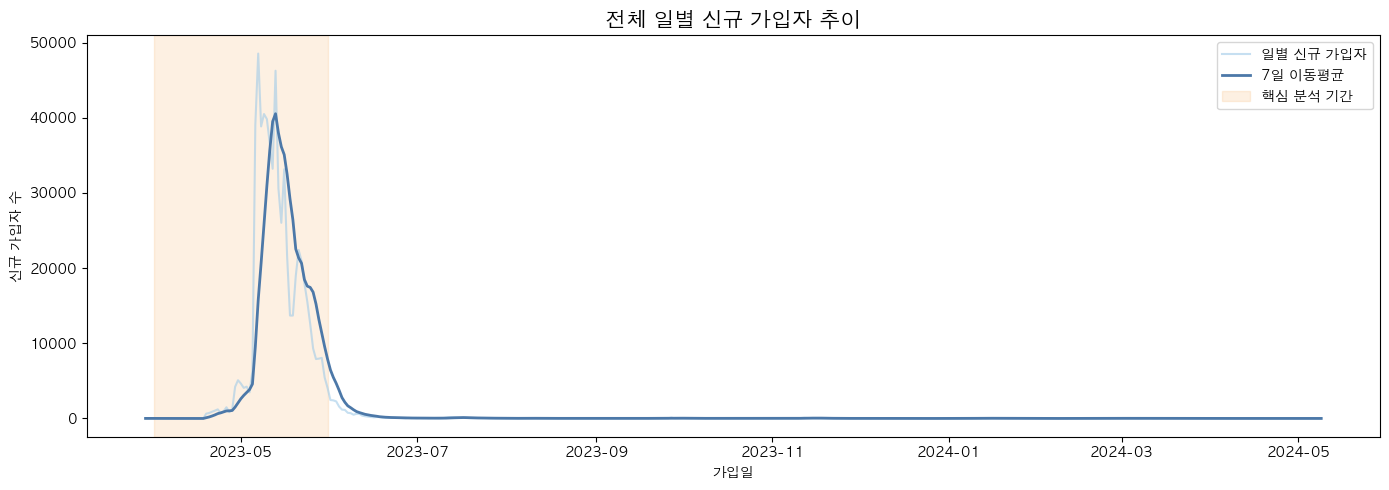

In [ ]:
# ============================================================
# 3. 전체 가입자 증가 추이
# ============================================================

# 일별 신규 가입자
daily_signup = (
    users
    .groupby("signup_date")["user_id"]
    .nunique()
    .rename("신규가입자수")
    .reset_index()
    .sort_values("signup_date")
)

# 달력 날짜를 채운 뒤 7일 이동평균 계산
calendar = pd.date_range(daily_signup["signup_date"].min(), daily_signup["signup_date"].max(), freq="D")
daily_signup = (daily_signup.set_index("signup_date")
                .reindex(calendar, fill_value=0)
                .rename_axis("signup_date").reset_index())

# 7일 이동평균
daily_signup["7일이동평균"] = (
    daily_signup["신규가입자수"]
    .rolling(window=7, min_periods=1)
    .mean()
)

# 월별 신규 가입자
monthly_signup = (
    users
    .groupby("signup_month")["user_id"]
    .nunique()
    .rename("신규가입자수")
    .reset_index()
    .sort_values("signup_month")
)

# 전월 대비 증가율
monthly_signup["전월대비증가율(%)"] = (
    monthly_signup["신규가입자수"]
    .pct_change()
    .mul(100)
)

print("월별 신규 가입자")
display(monthly_signup)

# 4월과 5월 비교
april_users = monthly_signup.loc[
    monthly_signup["signup_month"].eq("2023-04"),
    "신규가입자수"
].sum()

may_users = monthly_signup.loc[
    monthly_signup["signup_month"].eq("2023-05"),
    "신규가입자수"
].sum()

print("2023년 4월 가입자:", f"{april_users:,}명")
print("2023년 5월 가입자:", f"{may_users:,}명")

if april_users > 0:
    print(
        "5월/4월 가입자 배수:",
        f"{may_users / april_users:.2f}배"
    )

# 시각화
plt.figure(figsize=(14, 5))

plt.plot(
    daily_signup["signup_date"],
    daily_signup["신규가입자수"],
    color="#A0CBE8",
    alpha=0.6,
    label="일별 신규 가입자"
)

plt.plot(
    daily_signup["signup_date"],
    daily_signup["7일이동평균"],
    color="#4C78A8",
    linewidth=2,
    label="7일 이동평균"
)

plt.axvspan(
    pd.Timestamp("2023-04-01"),
    pd.Timestamp("2023-05-31"),
    color="#F58518",
    alpha=0.12,
    label="핵심 분석 기간"
)

plt.title(
    "전체 일별 신규 가입자 추이",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("가입일")
plt.ylabel("신규 가입자 수")
plt.legend()
plt.tight_layout()
plt.show()